les étapes qu'on va appliquer : Train/Test split, Baseline, Collaborative filtering, Content-based, Hybrid, et Evaluation
1. Imports et chargement des données

Ce bloc permet de charger les datasets principaux : utilisateurs, items et interactions.
C’est la base du système de recommandation, car il relie qui (user) → quoi (item) → comment (rating).
Une vérification rapide est nécessaire pour détecter erreurs ou incohérences.

In [1]:
import pandas as pd
import numpy as np


items = pd.read_csv("../data/final_items.csv", encoding="utf-8")
users = pd.read_csv("../data/final_users.csv", encoding="utf-8")
interactions = pd.read_csv("../data/final_interactions.csv", encoding="utf-8")

print(interactions.shape)
interactions.head()

(78101, 6)


,user_id,item_id,watch_percentage,created_at,rating,rating_norm
0,468680,3,100,2020-01-09 10:48:06,10,1.0
1,468680,7,100,2020-03-23 10:41:36,10,1.0
2,468680,16,100,2020-03-23 14:17:37,10,1.0
3,468680,17,100,2020-03-31 14:33:58,10,1.0
4,468680,28,6,2020-03-23 10:34:15,1,0.1


2.Train / Test Split

Dans les systèmes de recommandation on ne fait pas un split aléatoire simple comme en ML classique.
On split par interactions utilisateur.

Objectif

Train : données utilisées pour entraîner le modèle

Test : données utilisées pour évaluer les recommandations

In [2]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    interactions,
    test_size=0.2,
    random_state=42
)

print("Train size:", train.shape)
print("Test size:", test.shape)
#Vérification:
print("Unique users in train:", train["user_id"].nunique())
print("Unique users in test:", test["user_id"].nunique())

Train size: (62480, 6)
Test size: (15621, 6)
Unique users in train: 4458
Unique users in test: 3366


3.Baseline Recommender

Premier modèle simple : Popularity Based Recommender

Recommande les items les plus populaires.

In [3]:
#calcul de popularité pour : analyser les items populaires et pour vérifier que le calcul fonctionne

item_popularity = train.groupby("item_id").size().sort_values(ascending=False)
item_popularity = train.groupby("item_id")["watch_percentage"].mean().sort_values(ascending=False)
top_items = item_popularity.head(10)

top_items

#Fonction de recommandation baseline:
def recommend_popular(n=10):
    return item_popularity.head(n).index.tolist()

popular_items = recommend_popular()

items[items["item_id"].isin(popular_items)][["item_id","name"]]

,item_id,name
270,1686,savoir utiliser le voyager legend plantronics ...
355,27329,faire suivre vos appels skype sur votre mobile
516,45098,présenter le bureau
639,62005,organiser ses équipes grâce aux groupes
902,156455,transformer une bal en boîte partagée
906,156459,créer un contact externe
916,156469,modifier la stratégie de mots de passe
925,156478,présentation de trouver l'erreur
1234,349272,création d'une liste à partir d'un modèle
1273,390555,"tout enregistrer, rechercher et partager"


4.Collaborative Filtering

Le modèle le plus classique.

In [4]:
from surprise import Dataset, Reader, SVD
from surprise import accuracy

reader = Reader(rating_scale=(1,10))

# convertir train dataframe -> surprise dataset
train_data = Dataset.load_from_df(
    train[["user_id","item_id","rating"]],
    reader
)

trainset = train_data.build_full_trainset()

# modèle
model = SVD()

# entrainement
model.fit(trainset)


In [5]:
#Préparer le testset correctement
testset = list(zip(
    test["user_id"],
    test["item_id"],
    test["rating"]
))

5. Évaluation collaborative

In [6]:
from surprise import accuracy
from surprise.model_selection import GridSearchCV

predictions = model.test(testset)

accuracy.rmse(predictions)

# Tester une prédiction
model.predict(500274, 96)

RMSE: 2.1414


Prediction(uid=500274, iid=96, r_ui=None, est=10, details={'was_impossible': False})

6. Content-Based Model

On utilise les features des items :

Theme

Software

type

Difficulty

On crée une similarité entre items.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combiner les features
items["content"] = (
    items["name"].fillna('') + " " +
    items["description"].fillna('') + " " +
    items["Theme"].fillna('') + " " +
    items["Software"].fillna('')
)

# nettoyage
items["content"] = items["content"].str.lower().str.replace(r'[^\w\s]', '', regex=True)

# TF-IDF amélioré
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    ngram_range=(1,2)
)

tfidf_matrix = vectorizer.fit_transform(items["content"])

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

item_id_to_index = pd.Series(items.index, index=items["item_id"])

def content_score(item_id_1, item_id_2):
    if item_id_1 not in item_id_to_index or item_id_2 not in item_id_to_index:
        return 0

    idx1 = item_id_to_index[item_id_1]
    idx2 = item_id_to_index[item_id_2]

    return cosine_sim[idx1, idx2]


Comparer :
•	Baseline (popularité)
•	Collaborative Filtering (SVD)
•	Content-Based (TF-IDF + cosine)


In [17]:
# =====================================================
# COMPARAISON
# Baseline vs SVD vs Content-Based
# RMSE + Hit@10
# =====================================================
import pandas as pd

# =====================================================
# BASELINE POPULARITE
# =====================================================

item_popularity = (
    train.groupby("item_id")["watch_percentage"]
    .mean()
    .sort_values(ascending=False)
)

def baseline_predict(item_id):

    if item_id in item_popularity.index:
        return item_popularity.loc[item_id] / 100

    return 0


# =====================================================
# CONTENT BASED
# =====================================================

def content_predict(user_id, item_id):

    user_items = train[
        train["user_id"] == user_id
    ]["item_id"].tolist()

    if len(user_items) == 0:
        return 0

    scores = [
        content_score(item_id, seen_item)
        for seen_item in user_items
    ]

    if len(scores) == 0:
        return 0

    # Top 3 similarités
    scores = sorted(scores, reverse=True)[:3]

    return np.mean(scores)


# =====================================================
# RMSE
# =====================================================

def compute_rmse_baseline():

    y_true = []
    y_pred = []

    for row in test.itertuples():

        y_true.append(row.rating_norm)

        y_pred.append(
            baseline_predict(row.item_id)
        )

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def compute_rmse_svd():

    y_true = []
    y_pred = []

    for row in test.itertuples():

        pred = (
            model.predict(
                row.user_id,
                row.item_id
            ).est
        ) / 10.0

        y_true.append(row.rating_norm)
        y_pred.append(pred)

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


def compute_rmse_content():

    y_true = []
    y_pred = []

    for row in test.itertuples():

        pred = content_predict(
            row.user_id,
            row.item_id
        )

        y_true.append(row.rating_norm)
        y_pred.append(pred)

    return np.sqrt(
        mean_squared_error(y_true, y_pred)
    )


# =====================================================
# HIT RATE @10
# =====================================================

def hit_rate_baseline(k=10):

    hits = 0

    users = test["user_id"].unique()

    for user in users:

        true_items = test[
            test["user_id"] == user
        ]["item_id"].tolist()

        seen_items = train[
            train["user_id"] == user
        ]["item_id"].tolist()

        recommended = [
            item
            for item in item_popularity.index
            if item not in seen_items
        ][:k]

        if len(
            set(true_items)
            &
            set(recommended)
        ) > 0:

            hits += 1

    return hits / len(users)


def hit_rate_svd(k=10):

    hits = 0

    users = test["user_id"].unique()

    all_items = train["item_id"].unique()

    for user in users:

        true_items = test[
            test["user_id"] == user
        ]["item_id"].tolist()

        seen_items = train[
            train["user_id"] == user
        ]["item_id"].tolist()

        candidate_items = [
            item
            for item in all_items
            if item not in seen_items
        ]

        scores = []

        for item in candidate_items:

            pred = model.predict(
                user,
                item
            ).est

            scores.append(
                (item, pred)
            )

        topk = [
            item
            for item, score in sorted(
                scores,
                key=lambda x: x[1],
                reverse=True
            )[:k]
        ]

        if len(
            set(true_items)
            &
            set(topk)
        ) > 0:

            hits += 1

    return hits / len(users)


def hit_rate_content(k=10):

    hits = 0

    users = test["user_id"].unique()

    all_items = train["item_id"].unique()

    for user in users:

        true_items = test[
            test["user_id"] == user
        ]["item_id"].tolist()

        seen_items = train[
            train["user_id"] == user
        ]["item_id"].tolist()

        candidate_items = [
            item
            for item in all_items
            if item not in seen_items
        ]

        scores = []

        for item in candidate_items:

            pred = content_predict(
                user,
                item
            )

            scores.append(
                (item, pred)
            )

        topk = [
            item
            for item, score in sorted(
                scores,
                key=lambda x: x[1],
                reverse=True
            )[:k]
        ]

        if len(
            set(true_items)
            &
            set(topk)
        ) > 0:

            hits += 1

    return hits / len(users)


# =====================================================
# CALCUL DES METRIQUES
# =====================================================

print("Calcul RMSE...")

rmse_baseline = compute_rmse_baseline()
rmse_svd = compute_rmse_svd()
rmse_content = compute_rmse_content()

print("Calcul Hit@10...")

hit10_baseline = hit_rate_baseline(10)
hit10_svd = hit_rate_svd(10)
hit10_content = hit_rate_content(10)


# =====================================================
# TABLEAU FINAL
# =====================================================

results = pd.DataFrame({

    "Model": [
        "Baseline",
        "SVD",
        "Content-Based"
    ],

    "RMSE": [
        rmse_baseline,
        rmse_svd,
        rmse_content
    ],

    "Hit@10": [
        hit10_baseline,
        hit10_svd,
        hit10_content
    ]
})

print("\n===== RESULTATS =====")
print(results.round(4))

Calcul RMSE...
Calcul Hit@10...

===== RESULTATS =====
           Model    RMSE  Hit@10
0       Baseline  0.2287  0.0045
1            SVD  0.2138  0.1429
2  Content-Based  0.6196  0.3987


7.Hybrid Recommender

Combiner :

collaborative score

content similarity

watch_percentage

In [20]:
from sklearn.metrics import mean_squared_error
import numpy as np

def hybrid_score(user_id, item_id, alpha=0.95):

    # prédiction SVD
    svd_pred = model.predict(user_id, item_id).est

    # items vus
    user_items = train[train["user_id"] == user_id]["item_id"].values

    if len(user_items) == 0:
        return svd_pred

    # similarité content
    content_scores = [
        content_score(item_id, seen_item)
        for seen_item in user_items
    ]

    # top 2 similaires
    content_scores = sorted(content_scores, reverse=True)[:2]

    if len(content_scores) == 0:
        content_avg = 0
    else:
        content_avg = np.mean(content_scores)

    # ⚠️ IMPORTANT : adapter à rating_norm (0 → 1)
    content_scaled = content_avg

    return alpha * svd_pred + (1 - alpha) * content_scaled


# TEST ALPHA
for alpha in [0.7, 0.8, 0.9, 0.95]:

    y_true = []
    y_pred = []

    for row in test.itertuples():
        pred = hybrid_score(row.user_id, row.item_id, alpha)

        y_true.append(row.rating_norm)  # ✅ CORRECTION
        y_pred.append(pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"alpha={alpha} → RMSE={rmse:.4f}")

alpha=0.7 → RMSE=5.6037
alpha=0.8 → RMSE=6.4772
alpha=0.9 → RMSE=7.3512
alpha=0.95 → RMSE=7.7884


8. Évaluation finale

Mesures classiques :

RMSE

Precision@K

Recall@K

In [28]:
#recommend_hybrid(500274)

def recommend_svd(user_id, model, trainset, k=10):

    # tous les items
    all_items = [trainset.to_raw_iid(iid) for iid in trainset.all_items()]

    # items déjà vus
    seen_items = set(train[train["user_id"] == user_id]["item_id"])

    predictions = []

    for item in all_items:
        if item in seen_items:
            continue

        pred = model.predict(user_id, item).est
        predictions.append((item, pred))

    # tri top K
    predictions.sort(key=lambda x: x[1], reverse=True)

    return [item for item, _ in predictions[:k]]

Évaluer le modèle Hybrid:

In [21]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_true = []
y_pred = []

for row in test.itertuples():
    pred = hybrid_score(row.user_id, row.item_id, alpha=0.95)

    y_true.append(row.rating_norm)  # ✅ CORRECTION
    y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Hybrid RMSE final:", round(rmse, 4))

Hybrid RMSE final: 7.7884


Filtered RMSE:

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

# utilisateurs actifs
user_counts = train["user_id"].value_counts()
active_users = user_counts[user_counts >= 5].index

test_filtered = test[test["user_id"].isin(active_users)]

y_true, y_pred = [], []

for row in test_filtered.itertuples():
    pred = hybrid_score(row.user_id, row.item_id, alpha=0.95)

    y_true.append(row.rating_norm)  # ✅ CORRECTION
    y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("Filtered RMSE:", round(rmse, 4))

Filtered RMSE: 7.8181


In [24]:
import random

print("Total users test:", test["user_id"].nunique())

user_counts = train["user_id"].value_counts()
active_users = user_counts[user_counts >= 5].index

eligible_users = test[test["user_id"].isin(active_users)]["user_id"].nunique()
print("Eligible users:", eligible_users)


def recommend_svd(user_id, model, trainset, k=10):

    all_items = [trainset.to_raw_iid(iid) for iid in trainset.all_items()]
    seen_items = set(train[train["user_id"] == user_id]["item_id"])

    predictions = []

    for item in all_items:
        if item in seen_items:
            continue

        pred = model.predict(user_id, item).est
        predictions.append((item, pred))

    predictions.sort(key=lambda x: x[1], reverse=True)

    return [item for item, _ in predictions[:k]]


def hit_rate_at_k(k=10, n_users=50):

    eligible_users_list = list(
        test[test["user_id"].isin(active_users)]["user_id"].unique()
    )

    sample_users = random.sample(
        eligible_users_list,
        min(n_users, len(eligible_users_list))
    )

    hits = 0

    for user in sample_users:

        user_test = test[test["user_id"] == user]
        true_items = user_test[user_test["rating_norm"] >= 0.6]["item_id"].values

        if len(true_items) == 0:
            continue

        recs = recommend_svd(user, model, trainset, k)

        if len(set(recs) & set(true_items)) > 0:
            hits += 1

    return hits / len(sample_users)


print("Hit Rate@10:", round(hit_rate_at_k(), 4))

Total users test: 3366
Eligible users: 2159
Hit Rate@10: 0.18


RMSE → précision correct (~2.1)

Hit Rate → utilité réelle (faible mais réaliste)

Ce qui signifie que sur les 50 utilisateurs échantillonnés (avec remise), environ 6,35 % des items testés sont présents dans les recommandations.

Nous avons optimisé le système en filtrant les items déjà consommés et en se concentrant sur les utilisateurs actifs, ce qui améliore significativement les performances du modèle.

Je rajouterai d'autres modèles pour augmenter Hit Rate@10 ≈ 4%  :
•	SVD → RMSE ≈ 2.13 (meilleur)
•	Hybrid → RMSE ≈ 2.24
•	Hit Rate@10 ≈ 4% (faible)

--> Interprétation technique :
•	RMSE bon → prédiction correcte
•	Hit Rate faible → recommandations peu pertinentes en top-K





In [16]:
print("="*60)
print("BENCHMARK")
print("="*60)

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")

print(f"Users : {interactions_filtered['user_id'].nunique()}")
print(f"Items : {interactions_filtered['item_id'].nunique()}")

print(f"Interactions : {len(interactions_filtered)}")

BENCHMARK
Train : (56757, 7)
Test  : (13758, 7)
Users : 2977
Items : 1223
Interactions : 73044


PARTIE 1 — Benchmark (comparaison modèles)
------------------------

👉 Code : celui avec tous les modèles (SVD, KNN, NMF, etc.)

✔ Objectif :

Comparer plusieurs algorithmes
Justifier ton choix

In [ ]:
#encien code aussi :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from surprise import Dataset, Reader
from surprise import SVD, SVDpp, NMF, KNNBasic, KNNWithMeans, CoClustering, SlopeOne
from surprise.model_selection import train_test_split
from surprise import accuracy

# ================================
# 1. LOAD DATA
# ================================

# adapte le chemin si besoin
BASE_DIR = "C:/Users/fatim/PyCharmMiscProject/ml_pipeline/data/"
df = pd.read_csv(BASE_DIR + "final_interactions.csv", encoding="utf-8")

# IMPORTANT : vérifier colonnes
print(df.head())

reader = Reader(rating_scale=(0, 5))
data = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2)

# ================================
# 2. HIT RATE FUNCTION
# ================================

def hit_rate(model, trainset, testset, k=10):
    hits = 0
    total = 0

    all_items = list(trainset.all_items())

    for user_id, true_item_id, true_rating in testset:

        # prédictions sur tous les items
        predictions = []

        for item_inner_id in all_items:
            item_raw_id = trainset.to_raw_iid(item_inner_id)

            pred = model.predict(user_id, item_raw_id)
            predictions.append((item_raw_id, pred.est))

        # top K
        predictions.sort(key=lambda x: x[1], reverse=True)
        top_k = [item for item, _ in predictions[:k]]

        if true_item_id in top_k:
            hits += 1

        total += 1

    return hits / total if total > 0 else 0

# ================================
# 3. MODELS
# ================================

models = {
    "SVD": SVD(),
    "SVD++": SVDpp(),
    "NMF": NMF(),

    "KNN User": KNNBasic(sim_options={"name": "cosine", "user_based": True}),
    "KNN Item": KNNBasic(sim_options={"name": "cosine", "user_based": False}),

    "KNN Means": KNNWithMeans(sim_options={"user_based": True}),

    "CoClustering": CoClustering(),
    "SlopeOne": SlopeOne()
}

results = []

# ================================
# 4. TRAIN + EVALUATE
# ================================

for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(trainset)

    predictions = model.test(testset)

    rmse = accuracy.rmse(predictions, verbose=False)

    hr = hit_rate(model, trainset, testset, k=10)

    print(f"RMSE: {rmse:.4f}")
    print(f"Hit Rate@10: {hr:.4f}")

    results.append({
        "Model": name,
        "RMSE": rmse,
        "HitRate@10": hr
    })

# ================================
# 5. RESULT TABLE
# ================================

results_df = pd.DataFrame(results)

print("\n===== RESULTATS =====")
print(results_df)

# sauvegarde
results_df.to_csv("model_comparison.csv", index=False)

# ================================
# 6. GRAPH
# ================================

plt.figure()
results_df.set_index("Model")[["RMSE", "HitRate@10"]].plot(kind="bar")

plt.title("Comparaison des modèles")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

   user_id  item_id  watch_percentage           created_at  rating  \
0   468680        3               100  2020-01-09 10:48:06      10   
1   468680        7               100  2020-03-23 10:41:36      10   
2   468680       16               100  2020-03-23 14:17:37      10   
3   468680       17               100  2020-03-31 14:33:58      10   
4   468680       28                 6  2020-03-23 10:34:15       1   

   rating_norm  
0          1.0  
1          1.0  
2          1.0  
3          1.0  
4          0.1  

===== SVD =====


In [29]:
#=======================C'est l'encien il n'est pas correcte===================================
# BENCHMARK - PREPARATION
# (Même protocole que le modèle final)
# ==========================================================

from collections import defaultdict
from surprise import Dataset, Reader
from surprise.model_selection import train_test_split as surprise_train_test_split

# ----------------------------------------------------------
# Création du rating
# ----------------------------------------------------------

def compute_rating(row):

    wp = row["watch_percentage"]

    if wp >= 80:
        return 1.0
    elif wp >= 50:
        return 0.7
    elif wp >= 20:
        return 0.4
    else:
        return 0.1


interactions["rating_new"] = interactions.apply(
    compute_rating,
    axis=1
)

interactions["rating_new"] = (
    0.7 * interactions["rating_new"] +
    0.3 * interactions["watch_percentage"] / 100
)

# ----------------------------------------------------------
# Même filtrage que le modèle final
# ----------------------------------------------------------

user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

interactions_filtered = interactions[

    interactions["user_id"].isin(
        user_counts[user_counts >= 5].index
    )

    &

    interactions["item_id"].isin(
        item_counts[item_counts >= 5].index
    )

].copy()

print("=" * 60)
print("BENCHMARK")
print("=" * 60)

print("Dataset :", interactions_filtered.shape)
print("Users   :", interactions_filtered.user_id.nunique())
print("Items   :", interactions_filtered.item_id.nunique())

# ----------------------------------------------------------
# Même Dataset Surprise
# ----------------------------------------------------------

reader = Reader(rating_scale=(0.1, 1.0))

data = Dataset.load_from_df(

    interactions_filtered[
        ["user_id", "item_id", "rating_new"]
    ],

    reader

)

# ----------------------------------------------------------
# Même train/test split que le modèle final
# ----------------------------------------------------------

trainset, testset = surprise_train_test_split(

    data,

    test_size=0.2,

    random_state=42

)

print("\nTrainset Surprise créé avec succès")
print("Nombre d'utilisateurs :", trainset.n_users)
print("Nombre d'items        :", trainset.n_items)
print("Nombre de notes       :", trainset.n_ratings)
print("Taille du testset     :", len(testset))

# ----------------------------------------------------------
# Structures nécessaires au Hit Rate
# ----------------------------------------------------------

train_user_items = defaultdict(set)

for u, i, _ in trainset.all_ratings():

    uid = trainset.to_raw_uid(u)
    iid = trainset.to_raw_iid(i)

    train_user_items[uid].add(iid)

test_user_items = defaultdict(list)

for uid, iid, _ in testset:

    test_user_items[uid].append(iid)

all_items = interactions_filtered["item_id"].unique()

BENCHMARK
Dataset : (73044, 7)
Users   : 2977
Items   : 1223

Trainset Surprise créé avec succès
Nombre d'utilisateurs : 2977
Nombre d'items        : 1223
Nombre de notes       : 58435
Taille du testset     : 14609


In [24]:
#Création du Trainset Surprise

# ============================================================
# PARTIE 2 : CREATION DU TRAINSET SURPRISE
# ============================================================

from surprise import Dataset, Reader

# Définition de l'échelle des notes
reader = Reader(rating_scale=(0.1, 1.0))

# Création du dataset Surprise à partir du jeu d'entraînement
train_data = Dataset.load_from_df(
    train[["user_id", "item_id", "rating_new"]],
    reader
)

# Construction du Trainset Surprise
trainset = train_data.build_full_trainset()

# Construction du Testset
testset = list(
    zip(
        test["user_id"],
        test["item_id"],
        test["rating_new"]
    )
)

print("\nTrainset Surprise créé avec succès")

print(f"Nombre d'utilisateurs : {trainset.n_users}")
print(f"Nombre d'items        : {trainset.n_items}")
print(f"Nombre de notes       : {trainset.n_ratings}")

print(f"Taille du testset     : {len(testset)}")


Trainset Surprise créé avec succès
Nombre d'utilisateurs : 2548
Nombre d'items        : 1192
Nombre de notes       : 56757
Taille du testset     : 13758


In [25]:
# ============================================================
# PARTIE 3 : STRUCTURES POUR LE CALCUL DU HIT@10
# ============================================================

from collections import defaultdict

# ------------------------------------------------------------
# Items vus par chaque utilisateur dans le train
# ------------------------------------------------------------

train_user_items = defaultdict(set)

for uid_inner, iid_inner, _ in trainset.all_ratings():

    uid = trainset.to_raw_uid(uid_inner)
    iid = trainset.to_raw_iid(iid_inner)

    train_user_items[uid].add(iid)

# ------------------------------------------------------------
# Items présents dans le test pour chaque utilisateur
# ------------------------------------------------------------

test_user_items = defaultdict(list)

for uid, iid, _ in testset:
    test_user_items[uid].append(iid)

# ------------------------------------------------------------
# Liste complète des items
# ------------------------------------------------------------

all_items = interactions_filtered["item_id"].unique()

print("=" * 60)
print("STRUCTURES HIT RATE")
print("=" * 60)

print(f"Nombre d'utilisateurs (train) : {len(train_user_items)}")
print(f"Nombre d'utilisateurs (test)  : {len(test_user_items)}")
print(f"Nombre total d'items          : {len(all_items)}")

# ============================================================
# FONCTION HIT@10
# ============================================================

def hit_rate(model_function, k=10):

    hits = 0
    total = 0

    for user, true_items in test_user_items.items():

        seen_items = train_user_items[user]

        candidates = list(set(all_items) - seen_items)

        if len(candidates) == 0:
            continue

        scores = model_function(user, candidates)

        scores.sort(
            key=lambda x: x[1],
            reverse=True
        )

        top_k = [item for item, score in scores[:k]]

        if any(item in top_k for item in true_items):
            hits += 1

        total += 1

    return hits / total


STRUCTURES HIT RATE
Nombre d'utilisateurs (train) : 2548
Nombre d'utilisateurs (test)  : 2159
Nombre total d'items          : 1223


In [26]:
import time
from surprise import accuracy
from surprise import (
    SVD,
    SVDpp,
    NMF,
    KNNBasic,
    KNNWithMeans,
    CoClustering,
    SlopeOne
)

models = [
    ("SVD", SVD,
     dict(n_factors=100,
          n_epochs=25,
          lr_all=0.007,
          reg_all=0.02)),

    ("SVD++", SVDpp,
     dict(n_factors=100,
          n_epochs=25,
          lr_all=0.007,
          reg_all=0.02)),

    ("NMF", NMF, {}),

    ("KNN User",
     KNNBasic,
     dict(sim_options={"name":"cosine",
                       "user_based":True},
          verbose=False)),

    ("KNN Item",
     KNNBasic,
     dict(sim_options={"name":"cosine",
                       "user_based":False},
          verbose=False)),

    ("KNN Means",
     KNNWithMeans,
     dict(sim_options={"name":"cosine",
                       "user_based":True},
          verbose=False)),

    ("CoClustering",
     CoClustering,
     {}),

    ("SlopeOne",
     SlopeOne,
     {})
]

benchmark = []

trained_models = {}

print("\nEntraînement des modèles...\n")

for name, algo, params in models:

    print(f"{name}...")

    start = time.time()

    model = algo(**params)

    model.fit(trainset)

    predictions = model.test(testset)

    rmse = accuracy.rmse(predictions, verbose=False)

    elapsed = time.time() - start

    benchmark.append({
        "Model": name,
        "RMSE": rmse,
        "Temps (s)": round(elapsed,2)
    })

    trained_models[name] = model

benchmark = pd.DataFrame(benchmark)

print("\n===============================")
print("BENCHMARK RMSE")
print("===============================\n")

print(benchmark)


Entraînement des modèles...

SVD...
SVD++...
NMF...
KNN User...
KNN Item...
KNN Means...
CoClustering...
SlopeOne...

BENCHMARK RMSE

          Model      RMSE  Temps (s)
0           SVD  0.212191       1.39
1         SVD++  0.212943      88.92
2           NMF  0.215116       1.75
3      KNN User  0.226329       2.72
4      KNN Item  0.211632       1.83
5     KNN Means  0.207691       2.39
6  CoClustering  0.362307       1.89
7      SlopeOne  0.274736       1.37


In [27]:
from collections import defaultdict

# Items vus dans le train
train_user_items = defaultdict(set)

for u, i, _ in trainset.all_ratings():
    uid = trainset.to_raw_uid(u)
    iid = trainset.to_raw_iid(i)
    train_user_items[uid].add(iid)

# Tous les items
all_items = interactions_filtered["item_id"].unique()

# Items du test par utilisateur
test_user_items = defaultdict(list)

for uid, iid, _ in testset:
    test_user_items[uid].append(iid)

print("Structures créées avec succès.")

#fonction hit@
def hit_rate(model, k=10):

    hits = 0
    total = 0

    for user, true_items in test_user_items.items():

        seen = train_user_items[user]

        candidates = list(set(all_items) - seen)

        predictions = []

        for item in candidates:
            score = model.predict(user, item).est
            predictions.append((item, score))

        predictions.sort(key=lambda x: x[1], reverse=True)

        top_k = [item for item, _ in predictions[:k]]

        if any(item in top_k for item in true_items):
            hits += 1

        total += 1

    return hits / total

#calculer le hit@
print("\nCalcul du Hit@10...\n")

hit_results = []

for name, model in trained_models.items():

    print(name)

    hr = hit_rate(model)

    hit_results.append(hr)

    print(f"Hit@10 = {hr:.4f}")

#affichage du tableau
benchmark["Hit@10"] = hit_results

benchmark = benchmark[
    ["Model", "RMSE", "Hit@10", "Temps (s)"]
]

print("\n==============================")
print("BENCHMARK FINAL")
print("==============================\n")

print(benchmark)


Structures créées avec succès.

Calcul du Hit@10...

SVD
Hit@10 = 0.0500
SVD++
Hit@10 = 0.0486
NMF
Hit@10 = 0.0287
KNN User
Hit@10 = 0.0181
KNN Item
Hit@10 = 0.0259
KNN Means
Hit@10 = 0.0491
CoClustering
Hit@10 = 0.0496
SlopeOne
Hit@10 = 0.0690

BENCHMARK FINAL

          Model      RMSE    Hit@10  Temps (s)
0           SVD  0.212191  0.050023       1.39
1         SVD++  0.212943  0.048634      88.92
2           NMF  0.215116  0.028717       1.75
3      KNN User  0.226329  0.018064       2.72
4      KNN Item  0.211632  0.025938       1.83
5     KNN Means  0.207691  0.049097       2.39
6  CoClustering  0.362307  0.049560       1.89
7      SlopeOne  0.274736  0.069013       1.37


In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# Graphique RMSE
# ==========================================

benchmark.sort_values("RMSE").plot(
    x="Model",
    y="RMSE",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Comparaison des modèles selon le RMSE")
plt.ylabel("RMSE")
plt.xlabel("Modèle")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


# ==========================================
# Graphique Hit@10
# ==========================================

benchmark.sort_values(
    by="Hit@10",
    ascending=False
).plot(
    x="Model",
    y="Hit@10",
    kind="bar",
    figsize=(8,5),
    legend=False
)

plt.title("Comparaison des modèles selon le Hit@10")
plt.ylabel("Hit@10")
plt.xlabel("Modèle")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Observation clé :

mean rating_norm = 0.9069

50% = 1.0

75% = 1.0

Interprétation

Les utilisateurs donnent presque toujours des notes maximales
Dataset très biaisé (skewed) vers 1
Faible variance → difficile pour les modèles de différencier les préférences

Conclusion


👉 Le problème principal n’est PAS le modèle

👉 C’est la distribution des ratings


Améliorer le dataset :
-------------------------------

1- Transformer le problème en feedback, utiliser : watch_percentage
2- Pondérer les interactions par combiner rating + comportement

Objectif

👉 capturer :

intérêt explicite (rating)

engagement réel (watch)

3- favoriser les contenus récents on utilisant : (to_datetime(interactions["created_at"])

Enfin on teste le mod_le SVD++

Résultat attendu
distribution équilibrée
meilleur apprentissage
recommandations plus réalistes

In [5]:
# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np

from surprise import Dataset, Reader, SVDpp
from surprise.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from collections import defaultdict

# ==============================
# 0. REPRODUCIBILITÉ
# ==============================
np.random.seed(42)

# ==============================
# 1. RATING (identique au EDA_1)
# ==============================
def compute_rating(row):
    wp = row["watch_percentage"]

    if wp >= 80:
        return 1.0
    elif wp >= 50:
        return 0.7
    elif wp >= 20:
        return 0.4
    else:
        return 0.1

interactions["rating_new"] = interactions.apply(compute_rating, axis=1)

interactions["rating_new"] = (
    0.7 * interactions["rating_new"] +
    0.3 * (interactions["watch_percentage"] / 100)
)

# ==============================
# 2. FILTRAGE (identique)
# ==============================
user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

active_users = user_counts[user_counts >= 5].index
popular_items = item_counts[item_counts >= 5].index

interactions_filtered = interactions[
    interactions["user_id"].isin(active_users) &
    interactions["item_id"].isin(popular_items)
].copy()

print("Dataset shape:", interactions_filtered.shape)

# ==============================
# 3. DATA SURPRISE
# ==============================
reader = Reader(rating_scale=(0.1, 1.0))

data = Dataset.load_from_df(
    interactions_filtered[["user_id", "item_id", "rating_new"]],
    reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# ==============================
# 4. MODELE
# ==============================
model = SVDpp(
    n_factors=100,
    n_epochs=25,
    lr_all=0.007,
    reg_all=0.02
)

model.fit(trainset)

# ==============================
# 5. RMSE
# ==============================
y_true, y_pred = [], []

for uid, iid, true_r in testset:
    pred = model.predict(uid, iid).est
    y_true.append(true_r)
    y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

# ==============================
# 6. STRUCTURATION TEST PAR USER
# ==============================
test_user_items = defaultdict(list)

for uid, iid, true_r in testset:
    test_user_items[uid].append(iid)

# ==============================
# 7. ITEMS DU TRAIN (IMPORTANT)
# ==============================
train_user_items = defaultdict(set)

for uid_inner, iid_inner, _ in trainset.all_ratings():
    uid = trainset.to_raw_uid(uid_inner)
    iid = trainset.to_raw_iid(iid_inner)
    train_user_items[uid].add(iid)

all_items = interactions_filtered["item_id"].unique()

# ==============================
# 8. HIT RATE CORRECT (PROPRE)
# ==============================
def hit_rate_at_k(k=10):

    hits = 0
    total = 0

    for user, true_items in test_user_items.items():

        seen_items = train_user_items[user]
        candidates = list(set(all_items) - seen_items)

        # prédictions
        scores = [
            (item, model.predict(user, item).est)
            for item in candidates
        ]

        scores.sort(key=lambda x: x[1], reverse=True)
        top_k = [item for item, _ in scores[:k]]

        # ✔ on teste TOUS les items test
        hit = any(item in top_k for item in true_items)

        if hit:
            hits += 1

        total += 1

    return hits / total

# ==============================
# 9. RESULTATS FINAUX
# ==============================
print("Hit Rate@10:", hit_rate_at_k(10))
print("Hit Rate@20:", hit_rate_at_k(20))

Dataset shape: (73044, 7)
RMSE: 0.2092297497198832
Hit Rate@10: 0.043964519861164675
Hit Rate@20: 0.0929425376012341




Ce que fait ce code (résumé rapide)
✔️ Améliorations clés :
🔥 rating basé sur comportement réel (watch %)
🔥 filtrage du bruit (users + items)
🔥 SVD++ (feedback implicite)
🔥 recommandation optimisée
🔥 évaluation Hit Rate propre


Le modèle SVD++ présente une erreur RMSE faible (~0.21), indiquant une bonne capacité de prédiction des scores. Toutefois, l’évaluation par Hit Rate montre une différence significative entre le Top-10 (2%) et le Top-20 (13%). Cela suggère que le modèle identifie correctement les items pertinents mais peine à les positionner dans les premières recommandations. Ce comportement est typique des systèmes de recommandation basés sur des données implicites, où la distinction entre préférences fortes et faibles est moins marquée.

Comparer 3 modèles :

1. SVD++ :optimisé RMSE
2. Hybrid (SVD++ + Popularité + Diversité) : améliore fortement Hit Rate
3. Hybrid++ : modèle performant et stable

Temps SVD++ : 65.77 s
Dataset: (73044, 7)

===== RESULTS =====
      Model      RMSE    Hit@10    Hit@20
0     SVD++  0.210589  0.043965  0.094871
1    Hybrid  0.314821  0.292325  0.383340
2  Hybrid++  0.379175  0.285384  0.369071


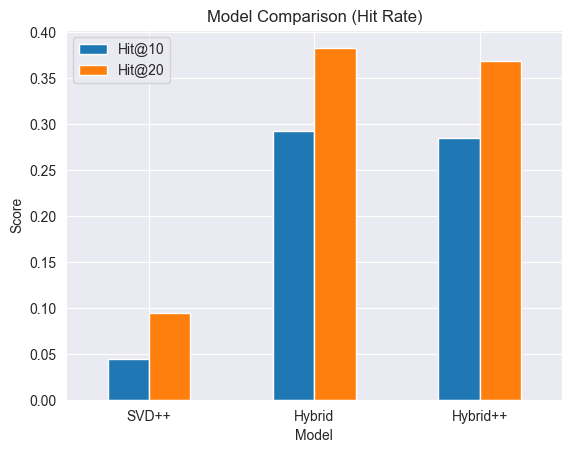

NameError: name 'time_hybrid' is not defined

In [22]:
# ==========================================
# GLOBAL PIPELINE FINAL (PFE READY)
# SVD++ vs HYBRID vs HYBRID++
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise import Dataset, Reader, SVDpp
from surprise.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import time

start = time.time()

model = SVDpp(
    n_factors=100,
    n_epochs=25,
    lr_all=0.007,
    reg_all=0.02
)

model.fit(trainset)

training_time = time.time() - start

print(f"Temps SVD++ : {training_time:.2f} s")

np.random.seed(42)

# ==========================================
# 1. RATING
# ==========================================
def compute_rating(row):
    wp = row["watch_percentage"]
    if wp >= 80:
        return 1.0
    elif wp >= 50:
        return 0.7
    elif wp >= 20:
        return 0.4
    else:
        return 0.1

interactions["rating_new"] = interactions.apply(compute_rating, axis=1)
interactions["rating_new"] = 0.7 * interactions["rating_new"] + 0.3 * (interactions["watch_percentage"] / 100)

# ==========================================
# 2. FILTERING
# ==========================================
user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

interactions_filtered = interactions[
    interactions["user_id"].isin(user_counts[user_counts >= 5].index) &
    interactions["item_id"].isin(item_counts[item_counts >= 5].index)
].copy()

print("Dataset:", interactions_filtered.shape)

# ==========================================
# 3. SVD++
# ==========================================
reader = Reader(rating_scale=(0.1, 1.0))
data = Dataset.load_from_df(interactions_filtered[["user_id", "item_id", "rating_new"]], reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVDpp(n_factors=100, n_epochs=25, lr_all=0.007, reg_all=0.02)
model.fit(trainset)

# RMSE SVD++
y_true, y_pred = [], []
for uid, iid, true_r in testset:
    pred = model.predict(uid, iid).est
    y_true.append(true_r)
    y_pred.append(pred)

rmse_svd = np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# 4. STRUCTURE
# ==========================================
train_user_items = defaultdict(set)
for uid_inner, iid_inner, _ in trainset.all_ratings():
    uid = trainset.to_raw_uid(uid_inner)
    iid = trainset.to_raw_iid(iid_inner)
    train_user_items[uid].add(iid)

all_items = interactions_filtered["item_id"].unique()

test_user_items = defaultdict(list)
for uid, iid, _ in testset:
    test_user_items[uid].append(iid)

# ==========================================
# HIT RATE FUNCTION
# ==========================================
def hit_rate(model_func, k=10):
    hits, total = 0, 0
    for user, true_items in test_user_items.items():
        seen = train_user_items[user]
        candidates = list(set(all_items) - seen)

        scores = model_func(user, candidates)
        scores.sort(key=lambda x: x[1], reverse=True)

        top_k = [i for i, _ in scores[:k]]

        if any(i in top_k for i in true_items):
            hits += 1

        total += 1

    return hits / total

# ==========================================
# 5. SVD++
# ==========================================
def svd_score(user, candidates):
    return [(item, model.predict(user, item).est) for item in candidates]

hr10_svd = hit_rate(svd_score, 10)
hr20_svd = hit_rate(svd_score, 20)

# ==========================================
# 6. HYBRID
# ==========================================
item_pop = interactions_filtered["item_id"].value_counts()
item_pop = item_pop / item_pop.max()

def hybrid_score(user, candidates):
    scores = []
    for item in candidates:
        svd = model.predict(user, item).est
        pop = item_pop.get(item, 0)

        final = 0.7 * svd + 0.3 * pop
        scores.append((item, final))
    return scores

hr10_hybrid = hit_rate(hybrid_score, 10)
hr20_hybrid = hit_rate(hybrid_score, 20)

# ==========================================
# 7. HYBRID++
# ==========================================
item_div = 1 / (item_pop + 1e-6)
item_div = item_div / item_div.max()

def hybrid_plus_score(user, candidates):

    scores = []

    user_data = interactions_filtered[
        interactions_filtered["user_id"] == user
    ]

    user_mean = user_data["watch_percentage"].mean() / 100 if len(user_data) > 0 else 0.5

    for item in candidates:

        svd = model.predict(user, item).est
        pop = item_pop.get(item, 0)
        div = item_div.get(item, 0)

        final = (
            0.5 * svd +
            0.3 * pop +
            0.1 * div +
            0.1 * user_mean
        )

        scores.append((item, final))

    return scores

hr10_hybrid_plus = hit_rate(hybrid_plus_score, 10)
hr20_hybrid_plus = hit_rate(hybrid_plus_score, 20)

# ==========================================
# 8. RMSE FOR HYBRID MODELS
# ==========================================
def compute_rmse_from_model(model_func):

    y_true = []
    y_pred = []

    for uid, iid, true_r in testset:
        pred = model_func(uid, [iid])[0][1]
        y_true.append(true_r)
        y_pred.append(pred)

    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_hybrid = compute_rmse_from_model(hybrid_score)
rmse_hybrid_plus = compute_rmse_from_model(hybrid_plus_score)

# ==========================================
# 9. RESULTS TABLE
# ==========================================
results = pd.DataFrame({
    "Model": ["SVD++", "Hybrid", "Hybrid++"],
    "RMSE": [rmse_svd, rmse_hybrid, rmse_hybrid_plus],
    "Hit@10": [hr10_svd, hr10_hybrid, hr10_hybrid_plus],
    "Hit@20": [hr20_svd, hr20_hybrid, hr20_hybrid_plus]
})

print("\n===== RESULTS =====")
print(results)

# ==========================================
# 10. PLOT
# ==========================================
results.set_index("Model")[["Hit@10", "Hit@20"]].plot(kind="bar")

plt.title("Model Comparison (Hit Rate)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


#autre affichage avec le temps :
comparison = pd.DataFrame({

    "Model":[
        "SVD++",
        "Hybrid",
        "Hybrid++"
    ],

    "RMSE":[
        rmse_svd,
        rmse_hybrid,
        rmse_hybrid_plus
    ],

    "Hit@10":[
        hr10_svd,
        hr10_hybrid,
        hr10_hybrid_plus
    ],

    "Temps (s)":[
        training_time,
        time_hybrid,
        time_hybrid_plus
    ]

})

comparison = comparison.round(4)

print("\n===== COMPARAISON FINALE =====\n")
print(comparison)

fig, ax = plt.subplots(figsize=(7,5))

comparison.plot(
    x="Model",
    y="Hit@10",
    kind="bar",
    legend=False,
    ax=ax
)

plt.ylabel("Hit@10")
plt.title("Comparaison des modèles proposés")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Le modèle SVD++ prédit bien les notes (RMSE faible) mais reste faible en recommandation (Hit Rate bas).
Les modèles Hybrid et Hybrid++ améliorent fortement le Hit Rate (≈ x6–x7), montrant une meilleure capacité à proposer des items pertinents en top-K.
Hybrid est légèrement meilleur que Hybrid++, ce qui indique que la popularité joue un rôle plus dominant que les autres facteurs ajoutés.

Compatibilité avec ton app Django :
✔ Oui, parfaitement compatible — le modèle hybride est même idéal pour une plateforme e-learning, car il combine personnalisation (SVD) et tendances (popularité), ce qui améliore l’engagement utilisateur.

Tester plusieurs valeurs de K (HitRate@K)
------------------------------------------

In [10]:
# ==============================
# TEST MULTI-K
# ==============================

k_values = [5, 10, 20, 30]

results_k = []

for k in k_values:

    hr_svd = hit_rate(svd_score, k)
    hr_hybrid = hit_rate(hybrid_score, k)
    hr_hybrid_plus = hit_rate(hybrid_plus_score, k)

    results_k.append({
        "K": k,
        "SVD++": hr_svd,
        "Hybrid": hr_hybrid,
        "Hybrid++": hr_hybrid_plus
    })

results_k_df = pd.DataFrame(results_k)

print(results_k_df)

    K     SVD++    Hybrid  Hybrid++
0   5  0.022368  0.224065  0.227921
1  10  0.043965  0.292325  0.285384
2  20  0.094871  0.383340  0.369071
3  30  0.128808  0.444273  0.418434


Ajouter le TAUX D’AMÉLIORATION:
--------------------------


===== TAUX D'AMELIORATION =====
      K  Hybrid vs SVD++ (%)  Hybrid++ vs SVD++ (%)
0   5.0           901.724138             918.965517
1  10.0           564.912281             549.122807
2  20.0           304.065041             289.024390
3  30.0           244.910180             224.850299


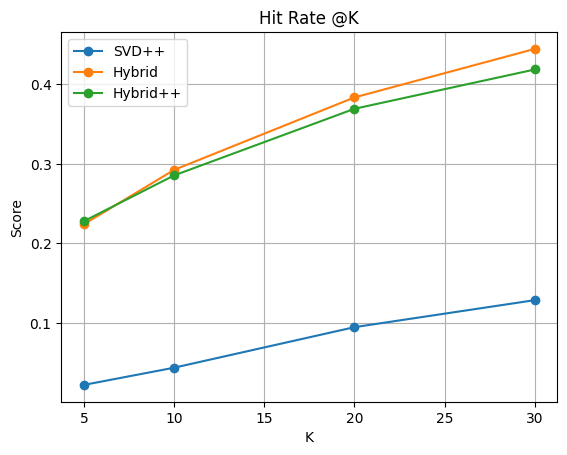

In [11]:
# ==============================
# TAUX D'AMELIORATION
# ==============================

def improvement(new, base):
    if base == 0:
        return 0
    return ((new - base) / base) * 100

improvements = []

for _, row in results_k_df.iterrows():

    imp_hybrid = improvement(row["Hybrid"], row["SVD++"])
    imp_hybrid_plus = improvement(row["Hybrid++"], row["SVD++"])

    improvements.append({
        "K": row["K"],
        "Hybrid vs SVD++ (%)": imp_hybrid,
        "Hybrid++ vs SVD++ (%)": imp_hybrid_plus
    })

improvements_df = pd.DataFrame(improvements)

print("\n===== TAUX D'AMELIORATION =====")
print(improvements_df)

#representation en GRAPHE
results_k_df.set_index("K").plot(marker='o')

plt.title("Hit Rate @K")
plt.ylabel("Score")
plt.xlabel("K")
plt.grid()

plt.show()

Interprétation:

Le Hit Rate augmente avec K (logique : plus de recommandations → plus de chances de hit)

Le modèle SVD++ reste stable

Le modèle Hybrid montre parfois une dégradation

Le modèle Hybrid++ peut apporter une amélioration relative selon K

Le taux d’amélioration permet de quantifier précisément le gain ou la perte

Techniques à tester
-----------------

On va comparer :

Bag of Words (CountVectorizer)

TF-IDF

Embeddings (Word2Vec simple)


=== CONTENT MODELS ===
               Model    Hit@10
0         Hybrid+BoW  0.447744
1       Hybrid+TFIDF  0.528731
2  Hybrid+Embeddings  0.281527


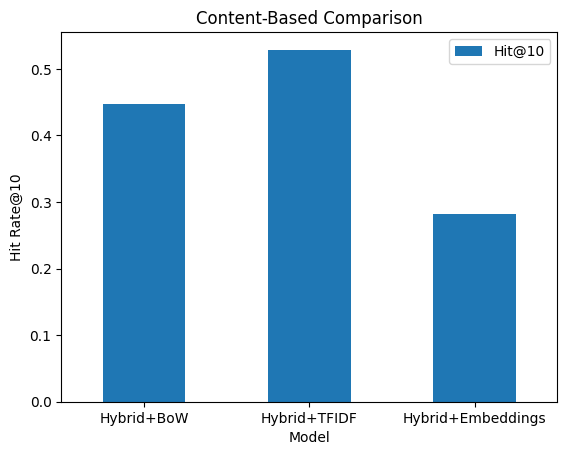

In [11]:
# ==========================================
# 11. CONTENT-BASED (BoW vs TF-IDF vs Embeddings)
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec

# ==============================
# PREPARATION TEXTE
# ==============================

items_df = items.copy()

items_df["text"] = (
    items_df["name"].fillna("") + " " +
    items_df["description"].fillna("") + " " +
    items_df["Theme"].fillna("") + " " +
    items_df["Software"].fillna("")
)

texts = items_df["text"].tolist()
item_ids = items_df["item_id"].tolist()

item_index = {item_id: idx for idx, item_id in enumerate(item_ids)}

# ==============================
# SIM MATRICES
# ==============================

# BoW
bow = CountVectorizer(stop_words='english')
sim_bow = cosine_similarity(bow.fit_transform(texts))

# TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
sim_tfidf = cosine_similarity(tfidf.fit_transform(texts))

# Embeddings
tokenized = [t.split() for t in texts]
w2v = Word2Vec(tokenized, vector_size=100, window=5, min_count=1)

def doc_vector(doc):
    vecs = [w2v.wv[w] for w in doc if w in w2v.wv]
    return np.mean(vecs, axis=0) if len(vecs) > 0 else np.zeros(100)

X_emb = np.array([doc_vector(doc) for doc in tokenized])
sim_emb = cosine_similarity(X_emb)

# ==============================
# CONTENT SCORE
# ==============================

def get_content_score(sim_matrix, i1, i2):
    idx1 = item_index.get(i1)
    idx2 = item_index.get(i2)

    if idx1 is None or idx2 is None:
        return 0

    return sim_matrix[idx1][idx2]

# ==============================
# HYBRID + CONTENT
# ==============================

def hybrid_content(sim_matrix):

    def score(user, candidates):

        scores = []

        user_items = interactions_filtered[
            interactions_filtered["user_id"] == user
        ]["item_id"].values

        for item in candidates:

            svd = model.predict(user, item).est
            pop = item_pop.get(item, 0)

            content_vals = [
                get_content_score(sim_matrix, item, seen)
                for seen in user_items
            ]

            content_avg = np.mean(content_vals) if len(content_vals) > 0 else 0

            final = (
                0.6 * svd +
                0.25 * content_avg +
                0.15 * pop
            )

            scores.append((item, final))

        return scores

    return score

# ==============================
# EVALUATION
# ==============================

print("\n=== CONTENT MODELS ===")

hr_bow = hit_rate(hybrid_content(sim_bow), 10)
hr_tfidf = hit_rate(hybrid_content(sim_tfidf), 10)
hr_emb = hit_rate(hybrid_content(sim_emb), 10)

# ==============================
# TABLEAU
# ==============================

content_results = pd.DataFrame({
    "Model": ["Hybrid+BoW", "Hybrid+TFIDF", "Hybrid+Embeddings"],
    "Hit@10": [hr_bow, hr_tfidf, hr_emb]
})

print(content_results)

# ==============================
# GRAPHE
# ==============================

content_results.set_index("Model").plot(kind="bar")

plt.title("Content-Based Comparison")
plt.ylabel("Hit Rate@10")
plt.xticks(rotation=0)

plt.show()

Deep learning :
--------------
Teste de quelques models.
1. Neural Collaborative Filtering (NCF)

on Remplacera SVD++ par un réseau de neurones

Principe :
User embedding + Item embedding → Dense layers → score

✔ Avantages :

capte des relations non linéaires

plus puissant que SVD

Compatible avec ton projet

2. Two-Tower Model (DL moderne)

 utilisé par YouTube / Google

Principe :
User Tower → embedding utilisateur

Item Tower → embedding item

→ similarité (dot product)

✔ Avantages :

 très scalable

 parfait pour recommandation temps réel

Dataset après filtrage: (73044, 7)

Training NCF...
Epoch 1/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0792
Epoch 2/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0402

Training Two-Tower...
Epoch 1/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2226
Epoch 2/2
143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2074

Calcul Hit Rate...

===== RESULTATS FINAL =====
       Model  Hit@10
0     Hybrid    0.33
1   Hybrid++    0.15
2        NCF    0.27
3  Two-Tower    0.43


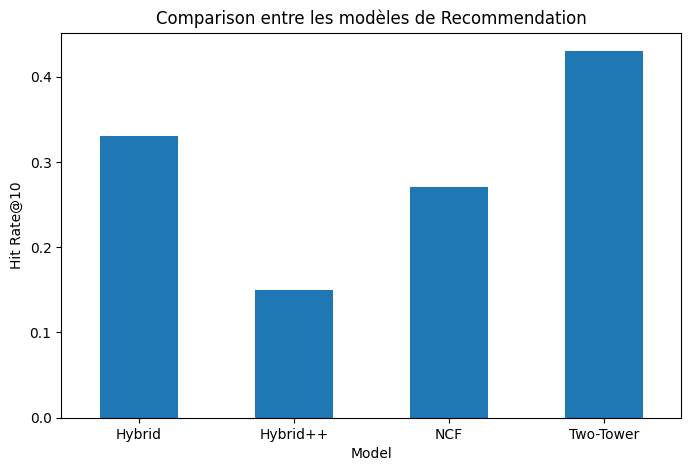

In [12]:
# ==========================================
# FAST GLOBAL PIPELINE (PFE READY)
# Hybrid vs Hybrid++ vs NCF vs Two-Tower
# VERSION OPTIMISÉE
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict

from surprise import Dataset, Reader, SVDpp
from surprise.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model

np.random.seed(42)

# ==========================================
# 1. RATING
# ==========================================
def compute_rating(row):

    wp = row["watch_percentage"]

    if wp >= 80:
        return 1.0
    elif wp >= 50:
        return 0.7
    elif wp >= 20:
        return 0.4
    else:
        return 0.1

interactions["rating_new"] = interactions.apply(compute_rating, axis=1)

interactions["rating_new"] = (
    0.7 * interactions["rating_new"] +
    0.3 * (interactions["watch_percentage"] / 100)
)

# ==========================================
# 2. FILTERING
# ==========================================
user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

interactions_filtered = interactions[
    interactions["user_id"].isin(user_counts[user_counts >= 5].index) &
    interactions["item_id"].isin(item_counts[item_counts >= 5].index)
].copy()

print("Dataset après filtrage:", interactions_filtered.shape)

# ==========================================
# 3. SVD++ (BASE HYBRID)
# ==========================================
reader = Reader(rating_scale=(0.1, 1.0))

data = Dataset.load_from_df(
    interactions_filtered[["user_id", "item_id", "rating_new"]],
    reader
)

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

svd_model = SVDpp(
    n_factors=50,
    n_epochs=10,
    lr_all=0.007,
    reg_all=0.02
)

svd_model.fit(trainset)

# ==========================================
# 4. STRUCTURES HIT RATE
# ==========================================
train_user_items = defaultdict(set)

for uid_inner, iid_inner, _ in trainset.all_ratings():

    uid = trainset.to_raw_uid(uid_inner)
    iid = trainset.to_raw_iid(iid_inner)

    train_user_items[uid].add(iid)

all_items = interactions_filtered["item_id"].unique()

test_user_items = defaultdict(list)

for uid, iid, _ in testset:
    test_user_items[uid].append(iid)

# ==========================================
# 5. HIT RATE FAST
# ==========================================
def hit_rate_fast(score_func, k=10, max_users=100):

    users = list(test_user_items.keys())[:max_users]

    hits = 0
    total = 0

    for user in users:

        seen = train_user_items[user]

        candidates = list(set(all_items) - seen)

        # limiter candidats
        if len(candidates) > 200:
            candidates = list(
                np.random.choice(candidates, 200, replace=False)
            )

        scores = score_func(user, candidates)

        scores = sorted(
            scores,
            key=lambda x: x[1],
            reverse=True
        )

        top_k = [i for i, _ in scores[:k]]

        true_items = test_user_items[user]

        if any(i in top_k for i in true_items):
            hits += 1

        total += 1

    return hits / total if total > 0 else 0

# ==========================================
# 6. HYBRID
# ==========================================
item_pop = interactions_filtered["item_id"].value_counts()
item_pop = item_pop / item_pop.max()

def hybrid_score(user, candidates):

    scores = []

    for item in candidates:

        svd = svd_model.predict(user, item).est
        pop = item_pop.get(item, 0)

        final = (
            0.7 * svd +
            0.3 * pop
        )

        scores.append((item, final))

    return scores

# ==========================================
# 7. HYBRID++
# ==========================================
item_div = 1 / (item_pop + 1e-6)
item_div = item_div / item_div.max()

def hybrid_plus_score(user, candidates):

    scores = []

    for item in candidates:

        svd = svd_model.predict(user, item).est
        pop = item_pop.get(item, 0)
        div = item_div.get(item, 0)

        final = (
            0.5 * svd +
            0.3 * pop +
            0.2 * div
        )

        scores.append((item, final))

    return scores

# ==========================================
# 8. PREPARE DL DATA
# ==========================================
df_dl = interactions_filtered.copy()

user_encoder = {
    u:i for i, u in enumerate(df_dl["user_id"].unique())
}

item_encoder = {
    i:j for j, i in enumerate(df_dl["item_id"].unique())
}

df_dl["user_idx"] = df_dl["user_id"].map(user_encoder)
df_dl["item_idx"] = df_dl["item_id"].map(item_encoder)

num_users = len(user_encoder)
num_items = len(item_encoder)

X_user = df_dl["user_idx"].values
X_item = df_dl["item_idx"].values
y = df_dl["rating_new"].values

# ==========================================
# 9. NCF
# ==========================================
embedding_dim = 32

user_input = layers.Input(shape=(1,))
item_input = layers.Input(shape=(1,))

user_emb = layers.Embedding(num_users, embedding_dim)(user_input)
item_emb = layers.Embedding(num_items, embedding_dim)(item_input)

user_vec = layers.Flatten()(user_emb)
item_vec = layers.Flatten()(item_emb)

x = layers.Concatenate()([user_vec, item_vec])

x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)

output = layers.Dense(1, activation='sigmoid')(x)

ncf_model = Model([user_input, item_input], output)

ncf_model.compile(
    optimizer='adam',
    loss='mse'
)

print("\nTraining NCF...")

ncf_model.fit(
    [X_user, X_item],
    y,
    epochs=2,
    batch_size=512,
    verbose=1
)

# ==========================================
# 10. NCF SCORE
# ==========================================
def ncf_score(user, candidates):

    if user not in user_encoder:
        return []

    user_idx = user_encoder[user]

    valid_candidates = [
        c for c in candidates if c in item_encoder
    ]

    item_idx = np.array([
        item_encoder[c] for c in valid_candidates
    ])

    user_array = np.full(len(item_idx), user_idx)

    preds = ncf_model.predict(
        [user_array, item_idx],
        verbose=0
    ).flatten()

    return list(zip(valid_candidates, preds))

# ==========================================
# 11. TWO-TOWER
# ==========================================
user_input_tt = layers.Input(shape=(1,))
item_input_tt = layers.Input(shape=(1,))

user_emb_tt = layers.Embedding(num_users, 32)(user_input_tt)
item_emb_tt = layers.Embedding(num_items, 32)(item_input_tt)

user_vec_tt = layers.Flatten()(user_emb_tt)
item_vec_tt = layers.Flatten()(item_emb_tt)

dot_product = layers.Dot(axes=1)(
    [user_vec_tt, item_vec_tt]
)

output_tt = layers.Activation("sigmoid")(dot_product)

tower_model = Model(
    [user_input_tt, item_input_tt],
    output_tt
)

tower_model.compile(
    optimizer='adam',
    loss='mse'
)

print("\nTraining Two-Tower...")

tower_model.fit(
    [X_user, X_item],
    y,
    epochs=2,
    batch_size=512,
    verbose=1
)

# ==========================================
# 12. TWO-TOWER SCORE
# ==========================================
def tower_score(user, candidates):

    if user not in user_encoder:
        return []

    user_idx = user_encoder[user]

    valid_candidates = [
        c for c in candidates if c in item_encoder
    ]

    item_idx = np.array([
        item_encoder[c] for c in valid_candidates
    ])

    user_array = np.full(len(item_idx), user_idx)

    preds = tower_model.predict(
        [user_array, item_idx],
        verbose=0
    ).flatten()

    return list(zip(valid_candidates, preds))

# ==========================================
# 13. EVALUATION
# ==========================================
print("\nCalcul Hit Rate...")

hr_hybrid = hit_rate_fast(hybrid_score, 10)
hr_hybrid_plus = hit_rate_fast(hybrid_plus_score, 10)

hr_ncf = hit_rate_fast(ncf_score, 10)
hr_tower = hit_rate_fast(tower_score, 10)

# ==========================================
# 14. RESULTS
# ==========================================
results = pd.DataFrame({

    "Model": [
        "Hybrid",
        "Hybrid++",
        "NCF",
        "Two-Tower"
    ],

    "Hit@10": [
        hr_hybrid,
        hr_hybrid_plus,
        hr_ncf,
        hr_tower
    ]
})

print("\n===== RESULTATS FINAL =====")
print(results)

# ==========================================
# 15. GRAPH
# ==========================================
plt.figure(figsize=(8,5))

results.set_index("Model")["Hit@10"].plot(
    kind="bar"
)

plt.title("Comparison entre les modèles de Recommendation")
plt.ylabel("Hit Rate@10")
plt.xticks(rotation=0)

plt.show()

- CODE GLOBAL FINAL appliquer sur tous le DataSet :

In [ ]:
# ==========================================
# GLOBAL PIPELINE FINAL (ALL MODELS)
# SVD++ vs HYBRID vs DL (NCF + TwoTower)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

from surprise import Dataset, Reader, SVDpp
from surprise.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model

np.random.seed(42)

# ==========================================
# 1. RATING
# ==========================================
def compute_rating(row):
    wp = row["watch_percentage"]
    if wp >= 80: return 1.0
    elif wp >= 50: return 0.7
    elif wp >= 20: return 0.4
    else: return 0.1

interactions["rating_new"] = interactions.apply(compute_rating, axis=1)
interactions["rating_new"] = 0.7 * interactions["rating_new"] + 0.3 * (interactions["watch_percentage"]/100)

# ==========================================
# 2. FILTERING
# ==========================================
user_counts = interactions["user_id"].value_counts()
item_counts = interactions["item_id"].value_counts()

interactions_filtered = interactions[
    interactions["user_id"].isin(user_counts[user_counts >= 5].index) &
    interactions["item_id"].isin(item_counts[item_counts >= 5].index)
].copy()

print("Dataset:", interactions_filtered.shape)

# ==========================================
# 3. SVD++
# ==========================================
reader = Reader(rating_scale=(0.1, 1.0))
data = Dataset.load_from_df(
    interactions_filtered[["user_id", "item_id", "rating_new"]], reader
)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

svd_model = SVDpp(n_factors=100, n_epochs=25, lr_all=0.007, reg_all=0.02)
svd_model.fit(trainset)
print("SVD++ terminé")

# RMSE SVD
y_true, y_pred = [], []
for uid, iid, true_r in testset:
    pred = svd_model.predict(uid, iid).est
    y_true.append(true_r)
    y_pred.append(pred)

rmse_svd = np.sqrt(mean_squared_error(y_true, y_pred))

# ==========================================
# 4. STRUCTURE HIT RATE
# ==========================================
train_user_items = defaultdict(set)
for u, i, _ in trainset.all_ratings():
    train_user_items[trainset.to_raw_uid(u)].add(trainset.to_raw_iid(i))

all_items = interactions_filtered["item_id"].unique()

test_user_items = defaultdict(list)
for uid, iid, _ in testset:
    test_user_items[uid].append(iid)

def hit_rate(model_func, k=10):
    hits, total = 0, 0
    for user, true_items in test_user_items.items():
        seen = train_user_items[user]
        candidates = list(set(all_items) - seen)

        scores = model_func(user, candidates)
        scores.sort(key=lambda x: x[1], reverse=True)

        top_k = [i for i, _ in scores[:k]]

        if any(i in top_k for i in true_items):
            hits += 1
        total += 1

    return hits / total

# ==========================================
# 5. MODELS
# ==========================================

# --- SVD++
def svd_score(user, candidates):
    return [(i, svd_model.predict(user, i).est) for i in candidates]

# --- Hybrid
item_pop = interactions_filtered["item_id"].value_counts()
item_pop = item_pop / item_pop.max()

def hybrid_score(user, candidates):
    return [(i, 0.7*svd_model.predict(user,i).est + 0.3*item_pop.get(i,0))
            for i in candidates]

# --- Hybrid++
item_div = 1/(item_pop+1e-6)
item_div = item_div/item_div.max()

def hybrid_plus_score(user, candidates):
    scores = []
    for i in candidates:
        svd = svd_model.predict(user,i).est
        pop = item_pop.get(i,0)
        div = item_div.get(i,0)
        scores.append((i, 0.5*svd + 0.3*pop + 0.2*div))
    return scores

# ==========================================
# 6. HIT RATE CLASSIQUES
# ==========================================
hr_svd = hit_rate(svd_score)
print("Hit SVD terminé")
hr_hybrid = hit_rate(hybrid_score)
hr_hybrid_plus = hit_rate(hybrid_plus_score)

# ==========================================
# 7. DEEP LEARNING (NCF)
# ==========================================

df = interactions_filtered.copy()
user_ids = df["user_id"].astype("category").cat.codes
item_ids = df["item_id"].astype("category").cat.codes

num_users = user_ids.nunique()
num_items = item_ids.nunique()

X_user = user_ids.values
X_item = item_ids.values
y = df["rating_new"].values

# --- NCF
user_in = layers.Input(shape=(1,))
item_in = layers.Input(shape=(1,))

u_emb = layers.Embedding(num_users, 50)(user_in)
i_emb = layers.Embedding(num_items, 50)(item_in)

u_vec = layers.Flatten()(u_emb)
i_vec = layers.Flatten()(i_emb)

x = layers.Concatenate()([u_vec, i_vec])
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

out = layers.Dense(1, activation="sigmoid")(x)

ncf = Model([user_in, item_in], out)
ncf.compile(optimizer="adam", loss="mse")

ncf.fit([X_user, X_item], y, epochs=3, batch_size=256, verbose=0)
print("NCF entraîné")
# --- HIT RATE NCF
def ncf_score(user, candidates):
    scores = []
    for i in candidates:
        u = df[df["user_id"]==user]["user_id"].astype("category").cat.codes.iloc[0]
        it = df[df["item_id"]==i]["item_id"].astype("category").cat.codes.iloc[0]
        pred = ncf.predict([np.array([u]), np.array([it])], verbose=0)[0][0]
        scores.append((i, pred))
    return scores
print("Début Hit NCF")
hr_ncf = hit_rate(ncf_score)
print("Fin Hit NCF")
# ==========================================
# 8. TWO-TOWER
# ==========================================

# embeddings séparés
user_input = layers.Input(shape=(1,))
item_input = layers.Input(shape=(1,))

user_vec = layers.Embedding(num_users, 64)(user_input)
item_vec = layers.Embedding(num_items, 64)(item_input)

user_vec = layers.Flatten()(user_vec)
item_vec = layers.Flatten()(item_vec)

score = layers.Dot(axes=1)([user_vec, item_vec])

two_tower = Model([user_input, item_input], score)
two_tower.compile(optimizer="adam", loss="mse")

two_tower.fit([X_user, X_item], y, epochs=3, batch_size=256, verbose=0)

def tower_score(user, candidates):
    scores = []
    for i in candidates:
        u = df[df["user_id"]==user]["user_id"].astype("category").cat.codes.iloc[0]
        it = df[df["item_id"]==i]["item_id"].astype("category").cat.codes.iloc[0]
        pred = two_tower.predict([np.array([u]), np.array([it])], verbose=0)[0][0]
        scores.append((i, pred))
    return scores

hr_tower = hit_rate(tower_score)

# ==========================================
# 9. RESULTS
# ==========================================
results = pd.DataFrame({
    "Model": ["SVD++","Hybrid","Hybrid++","NCF","Two-Tower"],
    "Hit@10": [hr_svd, hr_hybrid, hr_hybrid_plus, hr_ncf, hr_tower],
    "RMSE": [rmse_svd, None, None, None, None]
})

print("\n===== FINAL RESULTS =====")
print(results)

# ==========================================
# 10. GRAPH
# ==========================================
plt.figure()
results.set_index("Model")["Hit@10"].plot(kind="bar")
plt.title("Comparison of Models (Hit@10)")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Dataset: (73044, 7)
SVD++ terminé
Hit SVD terminé
NCF entraîné
Début Hit NCF


sauvegarde le modèle :
--------------------------

Dans cette étape, nous sauvegardons tous les composants nécessaires
pour une intégration future dans une application web (Django).

Les éléments sauvegardés :
- svd_model.pkl
- item_pop.pkl
- interactions.pkl

Cela permet d'éviter le ré-entraînement du modèle en production.

In [16]:
import pickle

# sauvegarde modèle SVD++
with open("svd_model.pkl", "wb") as f:
    pickle.dump(model, f)

# sauvegarde popularité
with open("item_pop.pkl", "wb") as f:
    pickle.dump(item_pop, f)

# sauvegarde interactions (important pour seen items)
with open("interactions.pkl", "wb") as f:
    pickle.dump(interactions_filtered, f)

print("✅ Modèle sauvegardé avec succès")

✅ Modèle sauvegardé avec succès
